In [1]:
import pandas as pd

df = pd.read_csv("amazon_sales_data_uncleaned.csv")

print(df.shape)
df.head(10)
df.info()
df.isna().sum().sort_values(ascending=False)
df.describe(include="all").T

(42675, 16)
<class 'pandas.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Title                     42675 non-null  str  
 1   Rating                    41651 non-null  str  
 2   Number_of_reviews         41651 non-null  str  
 3   bought_in_last_month      39458 non-null  str  
 4   Current/discounted_price  30926 non-null  str  
 5   Price_on_variant          42675 non-null  str  
 6   Listed_price              42675 non-null  str  
 7   is_best_seller            42675 non-null  str  
 8   is_sponsored              42675 non-null  str  
 9   is_couponed               42675 non-null  str  
 10  buy_box_availability      28022 non-null  str  
 11  delivery_details          30955 non-null  str  
 12  sustainability_badges     3408 non-null   str  
 13  image_url                 42675 non-null  str  
 14  product_url               40606 non-n

,count,unique,top,freq
Title,42675,8808,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",744
Rating,41651,31,4.6 out of 5 stars,6151
Number_of_reviews,41651,4413,25,626
bought_in_last_month,39458,59,100+ bought in past month,8801
Current/discounted_price,30926,2576,29.99,825
Price_on_variant,42675,3466,basic variant price: nan,21031
Listed_price,42675,911,No Discount,30364
is_best_seller,42675,12,No Badge,40814
is_sponsored,42675,2,Organic,35664
is_couponed,42675,42,No Coupon,40727


In [ ]:
print(df['Rating'].dropna().unique()[:10])
print(df['Number_of_reviews'].dropna().unique()[:10])
print(df['bought_in_last_month'].dropna().unique()[:15])

<StringArray>
['4.6 out of 5 stars', '4.3 out of 5 stars', '4.8 out of 5 stars',
 '4.5 out of 5 stars', '4.0 out of 5 stars', '4.7 out of 5 stars',
 '4.2 out of 5 stars', '4.4 out of 5 stars', '4.1 out of 5 stars',
 '4.9 out of 5 stars']
Length: 10, dtype: str
<StringArray>
[   '375',  '2,457',  '3,044', '35,882', '28,988', '44,522', '13,466',
 '38,105',  '4,380',  '7,308']
Length: 10, dtype: str
<StringArray>
[ '300+ bought in past month',   '6K+ bought in past month',
   '2K+ bought in past month',  '10K+ bought in past month',
 '100K+ bought in past month',  '100+ bought in past month',
   '1K+ bought in past month',  '500+ bought in past month',
  '80K+ bought in past month',  '70K+ bought in past month',
  '50K+ bought in past month',  '40K+ bought in past month',
  '60K+ bought in past month',  '20K+ bought in past month',
  '30K+ bought in past month']
Length: 15, dtype: str


In [ ]:
import re

df['rating_clean'] = df['Rating'].str.extract(r'([\d.]+)').astype(float)

df['reviews_clean'] = (
    df['Number_of_reviews']
    .str.replace(',', '', regex=False)
    .astype(float) 
)

def parse_bought(val):
    if pd.isna(val):
        return None
    match = re.match(r'([\d.]+)(K)?\+', val)
    if not match:
        return None
    num = float(match.group(1))
    if match.group(2) == 'K':
        num *= 1000
    return num

df['bought_last_month_clean'] = df['bought_in_last_month'].apply(parse_bought)

df[['Rating','rating_clean','Number_of_reviews','reviews_clean',
    'bought_in_last_month','bought_last_month_clean']].sample(10)

,Rating,rating_clean,Number_of_reviews,reviews_clean,bought_in_last_month,bought_last_month_clean
29147,4.7 out of 5 stars,4.7,"6,871",6871.0,200+ bought in past month,200.0
4831,4.6 out of 5 stars,4.6,"3,069",3069.0,600+ bought in past month,600.0
42443,4.0 out of 5 stars,4.0,104,104.0,50+ bought in past month,50.0
1723,4.8 out of 5 stars,4.8,172,172.0,1K+ bought in past month,1000.0
33435,3.7 out of 5 stars,3.7,168,168.0,100+ bought in past month,100.0
30046,4.5 out of 5 stars,4.5,"1,123",1123.0,300+ bought in past month,300.0
6235,4.4 out of 5 stars,4.4,76,76.0,400+ bought in past month,400.0
11058,4.5 out of 5 stars,4.5,77,77.0,50+ bought in past month,50.0
32780,4.8 out of 5 stars,4.8,"1,167",1167.0,No featured offers available,NaN
20436,3.9 out of 5 stars,3.9,16,16.0,No featured offers available,NaN


In [4]:
print(df['Current/discounted_price'].dropna().unique()[:10])
print(df['Listed_price'].unique()[:15])
print(df['Price_on_variant'].dropna().unique()[:10])

<StringArray>
[ '89.68',   '9.99',    '314',  '16.99',  '14.99',  '29.99', '249.99',
  '69.95',  '39.97',  '14.49']
Length: 10, dtype: str
<StringArray>
[    '$159.00',      '$15.99',     '$349.00', 'No Discount',      '$19.98',
      '$14.33',      '$17.99',      '$21.89',      '$20.00',      '$48.99',
      '$19.99',      '$38.98',      '$14.39',     '$169.99',      '$29.99']
Length: 15, dtype: str
<StringArray>
[ 'basic variant price: 2.4GHz',     'basic variant price: nan',
 'basic variant price: $162.24',  'basic variant price: $72.74',
  'basic variant price: $99.95',  'basic variant price: $88.11',
  'basic variant price: $23.04', 'basic variant price: $284.05',
 'basic variant price: $880.95',  'basic variant price: $17.45']
Length: 10, dtype: str


In [ ]:
df['current_price_clean'] = (
    df['Current/discounted_price']
    .str.replace(',', '', regex=False)
    .astype(float)
)

def parse_listed(val):
    if val == 'No Discount':
        return None
    return float(val.replace('$', '').replace(',', ''))

df['listed_price_clean'] = df['Listed_price'].apply(parse_listed)
df['listed_price_clean'] = df['listed_price_clean'].fillna(df['current_price_clean'])

df['discount_pct'] = (
    (df['listed_price_clean'] - df['current_price_clean']) / df['listed_price_clean'] * 100
).round(2)

print(df[['Listed_price','listed_price_clean','Current/discounted_price',
          'current_price_clean','discount_pct']].sample(10))

print("\nDiscount stats:")
print(df['discount_pct'].describe())

print("\nAny negative discounts (current > listed)?", (df['discount_pct'] < 0).sum())

      Listed_price  listed_price_clean Current/discounted_price  \
20722  No Discount                 NaN                      NaN   
29226  No Discount               82.99                    82.99   
8000   No Discount               39.99                    39.99   
2730   No Discount               49.95                    49.95   
39162       $25.99               25.99                    18.99   
19864  No Discount                 NaN                      NaN   
13555       $29.99               29.99                    25.49   
8535       $499.99              499.99                   449.99   
38792  No Discount              119.99                   119.99   
14455  No Discount               68.99                    68.99   

       current_price_clean  discount_pct  
20722                  NaN           NaN  
29226                82.99          0.00  
8000                 39.99          0.00  
2730                 49.95          0.00  
39162                18.99         26.93  
1986

In [7]:
print(df['is_best_seller'].value_counts())
print()
print(df['is_couponed'].value_counts())

is_best_seller
No Badge             40814
Amazon's               744
Limited time deal      409
Best Seller            275
Save 30%               125
Ends in                 97
Save 10%                61
Save 18%                57
Save 17%                51
Save 12%                26
Save 9%                 14
Save 77%                 2
Name: count, dtype: int64

is_couponed
No Coupon                                    40727
Save $16.00  with coupon                       438
Save 15%  with coupon                          398
Save 10%  with coupon                          218
Save 5%  with coupon                           191
Save 50%  with coupon                          123
Save $11.00  with coupon                       120
Save $100.00  with coupon                       97
Save 40%  with coupon                           96
Save $25.00  with coupon                        65
Save $30.00  with coupon                        49
Save $69.00  with coupon                        31
Save 8%  w

In [ ]:
df['badge_best_seller'] = df['is_best_seller'] == 'Best Seller'
df['badge_amazons_choice'] = df['is_best_seller'] == "Amazon's"
df['badge_limited_deal'] = df['is_best_seller'].isin(['Limited time deal', 'Ends in'])

df['badge_deal_pct'] = df['is_best_seller'].str.extract(r'Save (\d+)%').astype(float)

df[['is_best_seller','badge_best_seller','badge_amazons_choice',
    'badge_limited_deal','badge_deal_pct']].drop_duplicates(subset='is_best_seller')

,is_best_seller,badge_best_seller,badge_amazons_choice,badge_limited_deal,badge_deal_pct
0,No Badge,False,False,False,NaN
3,Best Seller,True,False,False,NaN
71,Amazon's,False,True,False,NaN
1474,Limited time deal,False,False,True,NaN
26027,Save 30%,False,False,False,30.0
26338,Save 12%,False,False,False,12.0
26758,Save 9%,False,False,False,9.0
28292,Save 17%,False,False,False,17.0
30400,Save 77%,False,False,False,77.0
39855,Ends in,False,False,True,NaN


In [ ]:
df['has_coupon'] = df['is_couponed'] != 'No Coupon'

df['coupon_pct'] = df['is_couponed'].str.extract(r'Save (\d+)%\s*with coupon').astype(float)
df['coupon_dollar'] = df['is_couponed'].str.extract(r'Save \$([\d.]+)\s*with coupon').astype(float)

df[['is_couponed','has_coupon','coupon_pct','coupon_dollar']].drop_duplicates(subset='is_couponed').head(15)

,is_couponed,has_coupon,coupon_pct,coupon_dollar
0,Save 15% with coupon,True,15.0,NaN
1,No Coupon,False,NaN,NaN
8,Save 50% with coupon,True,50.0,NaN
57,Save $16.00 with coupon,True,NaN,16.00
58,Save $10.00 with coupon,True,NaN,10.00
129,Save 10% with coupon,True,10.0,NaN
172,Save $20.00 with coupon,True,NaN,20.00
207,Save $4.00 with coupon,True,NaN,4.00
261,Save $0.33 with coupon,True,NaN,0.33
267,Save $18.00 with coupon,True,NaN,18.00


In [ ]:
df['has_sustainability_badge'] = df['sustainability_badges'].notna()

df['buy_box_available'] = df['buy_box_availability'].notna()

print(df['has_sustainability_badge'].value_counts())
print(df['buy_box_available'].value_counts())

has_sustainability_badge
False    39267
True      3408
Name: count, dtype: int64
buy_box_available
True     28022
False    14653
Name: count, dtype: int64


In [11]:
categories = {
    'Electronics': ['charger','cable','headphone','earbud','bluetooth','battery','usb','laptop','phone','camera','speaker','tv','monitor'],
    'Home & Kitchen': ['kitchen','cookware','pan','knife','storage','furniture','decor','bedding','pillow','towel'],
    'Beauty': ['skincare','makeup','shampoo','lotion','serum','cream','fragrance','perfume'],
    'Clothing': ['shirt','dress','pants','jacket','shoes','socks','jeans','sweater'],
    'Sports & Outdoors': ['fitness','yoga','bike','camping','hiking','sports','gym','exercise'],
    'Toys & Games': ['toy','game','puzzle','lego','doll'],
    'Pet Supplies': ['dog','cat','pet','leash','aquarium'],
    'Books': ['book','novel','paperback','hardcover'],
    'Health': ['vitamin','supplement','medicine','first aid'],
}

def infer_category(title):
    title_lower = title.lower()
    for cat, keywords in categories.items():
        if any(kw in title_lower for kw in keywords):
            return cat
    return 'Other'

df['category_inferred'] = df['Title'].apply(infer_category)
print(df['category_inferred'].value_counts())

category_inferred
Electronics          22558
Other                17968
Home & Kitchen        1167
Books                  379
Toys & Games           270
Pet Supplies           232
Sports & Outdoors       80
Clothing                17
Beauty                   4
Name: count, dtype: int64


In [12]:
categories['Electronics'] = ['headphone','earbud','bluetooth','laptop','monitor','charger','speaker','camera','tv ','smartphone']

df['category_inferred'] = df['Title'].apply(infer_category)
print(df['category_inferred'].value_counts())

category_inferred
Other                23375
Electronics          16388
Home & Kitchen        1355
Books                  715
Toys & Games           369
Pet Supplies           267
Sports & Outdoors      177
Clothing                20
Beauty                   9
Name: count, dtype: int64


Top 1% of products account for 36.2% of total purchases
Top 5% of products account for 77.4% of total purchases
Top 10% of products account for 84.1% of total purchases
Top 25% of products account for 91.6% of total purchases
Top 50% of products account for 96.5% of total purchases


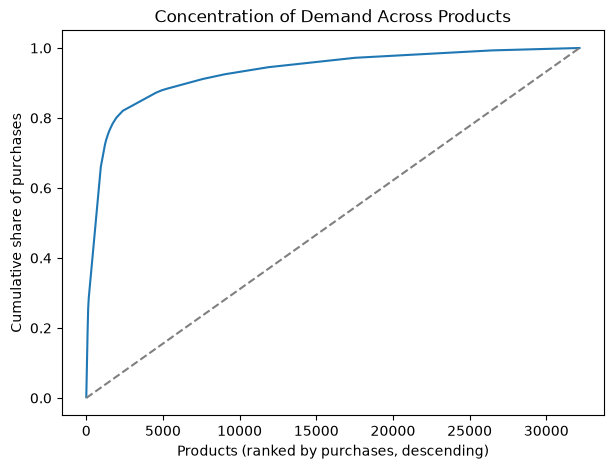

In [ ]:
import matplotlib.pyplot as plt

demand = df['bought_last_month_clean'].dropna().sort_values(ascending=False)

total = demand.sum()
n = len(demand)

for pct in [0.01, 0.05, 0.10, 0.25, 0.50]:
    top_n = int(n * pct)
    share = demand.iloc[:top_n].sum() / total * 100
    print(f"Top {pct*100:.0f}% of products account for {share:.1f}% of total purchases")

cum_share = demand.cumsum() / total
plt.figure(figsize=(7,5))
plt.plot(range(1, n+1), cum_share.values)
plt.plot([0, n], [0, 1], linestyle='--', color='gray')
plt.xlabel('Products (ranked by purchases, descending)')
plt.ylabel('Cumulative share of purchases')
plt.title('Concentration of Demand Across Products')
plt.show()

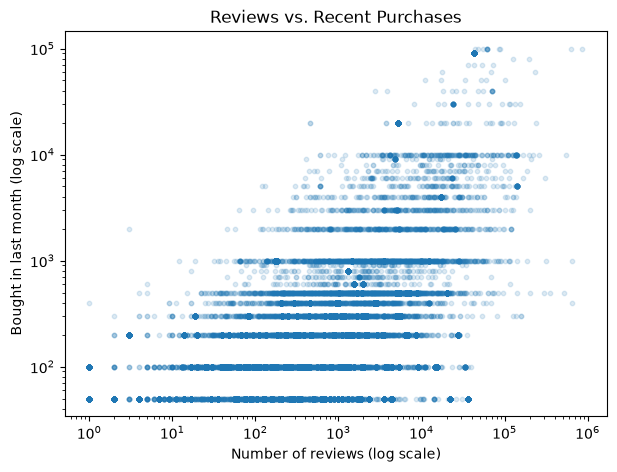

Log-log correlation: 0.483


In [ ]:
import numpy as np

plot_df = df[['reviews_clean', 'bought_last_month_clean']].dropna()
plot_df = plot_df[(plot_df['reviews_clean'] > 0) & (plot_df['bought_last_month_clean'] > 0)]

plt.figure(figsize=(7,5))
plt.scatter(plot_df['reviews_clean'], plot_df['bought_last_month_clean'], alpha=0.15, s=10)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of reviews (log scale)')
plt.ylabel('Bought in last month (log scale)')
plt.title('Reviews vs. Recent Purchases')
plt.show()

log_corr = np.corrcoef(np.log(plot_df['reviews_clean']), np.log(plot_df['bought_last_month_clean']))[0,1]
print(f"Log-log correlation: {log_corr:.3f}")

In [ ]:
valid_cats = df['category_inferred'].value_counts()
valid_cats = valid_cats[valid_cats >= 200].index

price_demand = df[df['category_inferred'].isin(valid_cats)][
    ['category_inferred', 'current_price_clean', 'bought_last_month_clean']
].dropna()

def price_quartile_analysis(group):
    group = group.copy()
    try:
        group['price_bin'] = pd.qcut(group['current_price_clean'], 4, duplicates='drop')
    except ValueError:
        return None
    return group.groupby('price_bin')['bought_last_month_clean'].median()

for cat in valid_cats:
    print(f"\n--- {cat} ---")
    subset = price_demand[price_demand['category_inferred'] == cat]
    result = price_quartile_analysis(subset)
    print(result)


--- Other ---
price_bin
(2.4890000000000003, 19.99]    500.0
(19.99, 49.545]                200.0
(49.545, 152.0]                100.0
(152.0, 3999.0]                 50.0
Name: bought_last_month_clean, dtype: float64

--- Electronics ---
price_bin
(3.999, 29.99]      400.0
(29.99, 71.89]      200.0
(71.89, 159.95]     200.0
(159.95, 4198.0]     50.0
Name: bought_last_month_clean, dtype: float64

--- Home & Kitchen ---
price_bin
(2.9890000000000003, 25.49]    300.0
(25.49, 93.99]                 100.0
(93.99, 112.08]                100.0
(112.08, 1299.99]              100.0
Name: bought_last_month_clean, dtype: float64

--- Books ---
price_bin
(6.388999999999999, 29.99]    200.0
(29.99, 263.99]                50.0
(263.99, 1889.0]              100.0
Name: bought_last_month_clean, dtype: float64

--- Toys & Games ---
price_bin
(4.968999999999999, 12.16]    300.0
(12.16, 19.99]                600.0
(19.99, 719.99]               500.0
Name: bought_last_month_clean, dtype: float64

--- Pe

In [16]:
discount_demand = df[df['category_inferred'].isin(valid_cats)][
    ['category_inferred', 'discount_pct', 'bought_last_month_clean']
].dropna()

# bin into discount tiers
bins = [-0.01, 0, 10, 20, 30, 100]
labels = ['0%', '1-10%', '10-20%', '20-30%', '30%+']
discount_demand['discount_bin'] = pd.cut(discount_demand['discount_pct'], bins=bins, labels=labels)

for cat in valid_cats:
    print(f"\n--- {cat} ---")
    subset = discount_demand[discount_demand['category_inferred'] == cat]
    print(subset.groupby('discount_bin', observed=True)['bought_last_month_clean'].median())


--- Other ---
discount_bin
0%        200.0
1-10%     200.0
10-20%    400.0
20-30%    100.0
30%+      400.0
Name: bought_last_month_clean, dtype: float64

--- Electronics ---
discount_bin
0%        200.0
1-10%     100.0
10-20%    200.0
20-30%    200.0
30%+      200.0
Name: bought_last_month_clean, dtype: float64

--- Home & Kitchen ---
discount_bin
0%         100.0
1-10%      400.0
10-20%     200.0
20-30%    1000.0
30%+      1000.0
Name: bought_last_month_clean, dtype: float64

--- Books ---
discount_bin
0%        400.0
1-10%     500.0
10-20%    300.0
20-30%    500.0
30%+      200.0
Name: bought_last_month_clean, dtype: float64

--- Toys & Games ---
discount_bin
0%        600.0
10-20%    450.0
20-30%    700.0
30%+      300.0
Name: bought_last_month_clean, dtype: float64

--- Pet Supplies ---
discount_bin
0%         100.0
1-10%      200.0
10-20%     250.0
20-30%     100.0
30%+      3500.0
Name: bought_last_month_clean, dtype: float64


In [17]:
compare_cols = ['current_price_clean', 'discount_pct', 'rating_clean', 
                'reviews_clean', 'bought_last_month_clean', 'badge_best_seller']

sponsored_compare = df.groupby('is_sponsored')[compare_cols].median(numeric_only=True)
print(sponsored_compare)

print("\nBest Seller rate by sponsorship:")
print(df.groupby('is_sponsored')['badge_best_seller'].mean())

print("\nSample sizes:")
print(df['is_sponsored'].value_counts())

              current_price_clean  discount_pct  rating_clean  reviews_clean  \
is_sponsored                                                                   
Organic                     79.99           0.0           4.5          383.0   
Sponsored                   69.95           0.0           4.5          180.0   

              bought_last_month_clean  badge_best_seller  
is_sponsored                                              
Organic                         200.0                0.0  
Sponsored                      1000.0                0.0  

Best Seller rate by sponsorship:
is_sponsored
Organic      0.006169
Sponsored    0.007845
Name: badge_best_seller, dtype: float64

Sample sizes:
is_sponsored
Organic      35664
Sponsored     7011
Name: count, dtype: int64


In [18]:
compare_cols = ['current_price_clean', 'discount_pct', 'rating_clean',
                'reviews_clean', 'bought_last_month_clean', 'has_coupon']

bs_compare = df.groupby('badge_best_seller')[compare_cols].median(numeric_only=True)
print(bs_compare)

print("\nSponsored rate by Best Seller status:")
print(df.groupby('badge_best_seller')['is_sponsored'].apply(lambda x: (x=='Sponsored').mean()))

print("\nSample sizes:")
print(df['badge_best_seller'].value_counts())

                   current_price_clean  discount_pct  rating_clean  \
badge_best_seller                                                    
False                            77.00          0.00           4.5   
True                             39.99         18.34           4.6   

                   reviews_clean  bought_last_month_clean  has_coupon  
badge_best_seller                                                      
False                      340.0                    200.0         0.0  
True                      8449.0                   6000.0         0.0  

Sponsored rate by Best Seller status:
badge_best_seller
False    0.164057
True     0.200000
Name: is_sponsored, dtype: float64

Sample sizes:
badge_best_seller
False    42400
True       275
Name: count, dtype: int64


In [19]:
seg_df = df[['Title', 'reviews_clean', 'bought_last_month_clean', 'category_inferred']].dropna(
    subset=['reviews_clean', 'bought_last_month_clean']
)

review_median = seg_df['reviews_clean'].median()
purchase_median = seg_df['bought_last_month_clean'].median()

def segment(row):
    high_reviews = row['reviews_clean'] >= review_median
    high_purchases = row['bought_last_month_clean'] >= purchase_median
    if high_reviews and high_purchases:
        return 'Established winners'
    elif not high_reviews and high_purchases:
        return 'Emerging winners'
    elif high_reviews and not high_purchases:
        return 'Mature/niche'
    else:
        return 'Weak products'

seg_df['segment'] = seg_df.apply(segment, axis=1)

print(f"Review median: {review_median}, Purchase median: {purchase_median}\n")
print(seg_df['segment'].value_counts())
print("\nSegment share by category:")
print(pd.crosstab(seg_df['category_inferred'], seg_df['segment'], normalize='index').round(2))

Review median: 686.0, Purchase median: 200.0

segment
Established winners    11846
Weak products          10422
Emerging winners        5546
Mature/niche            4274
Name: count, dtype: int64

Segment share by category:
segment            Emerging winners  Established winners  Mature/niche  \
category_inferred                                                        
Beauty                         0.38                 0.50          0.00   
Books                          0.04                 0.62          0.01   
Clothing                       0.20                 0.75          0.05   
Electronics                    0.17                 0.34          0.18   
Home & Kitchen                 0.06                 0.42          0.04   
Other                          0.19                 0.38          0.10   
Pet Supplies                   0.07                 0.29          0.27   
Sports & Outdoors              0.48                 0.20          0.02   
Toys & Games                   0.05 

In [ ]:
from sklearn.model_selection import train_test_split

feature_cols = [
    'current_price_clean', 'discount_pct', 'rating_clean', 'reviews_clean',
    'is_sponsored', 'has_coupon', 'has_sustainability_badge', 'buy_box_available'
]

model_df = df[feature_cols + ['badge_best_seller']].copy()

model_df['is_sponsored'] = (model_df['is_sponsored'] == 'Sponsored').astype(int)
model_df['has_coupon'] = model_df['has_coupon'].astype(int)
model_df['has_sustainability_badge'] = model_df['has_sustainability_badge'].astype(int)
model_df['buy_box_available'] = model_df['buy_box_available'].astype(int)

print("Rows before dropna:", len(model_df))
model_df = model_df.dropna()
print("Rows after dropna:", len(model_df))
print("\nBest Seller count in modeling set:")
print(model_df['badge_best_seller'].value_counts())

Rows before dropna: 42675
Rows after dropna: 30337

Best Seller count in modeling set:
badge_best_seller
False    30112
True       225
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

X = model_df[feature_cols]
y = model_df['badge_best_seller']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train Best Seller count:", y_train.sum(), "/", len(y_train))
print("Test Best Seller count:", y_test.sum(), "/", len(y_test))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

print("\n--- Logistic Regression Results ---")
print(classification_report(y_test, y_pred, target_names=['Not Best Seller', 'Best Seller']))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Train Best Seller count: 180 / 24269
Test Best Seller count: 45 / 6068

--- Logistic Regression Results ---
                 precision    recall  f1-score   support

Not Best Seller       1.00      0.85      0.92      6023
    Best Seller       0.03      0.69      0.06        45

       accuracy                           0.84      6068
      macro avg       0.51      0.77      0.49      6068
   weighted avg       0.99      0.84      0.91      6068


Confusion matrix:
[[5095  928]
 [  14   31]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=42, max_depth=8
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("--- Random Forest Results ---")
print(classification_report(y_test, y_pred_rf, target_names=['Not Best Seller', 'Best Seller']))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

--- Random Forest Results ---
                 precision    recall  f1-score   support

Not Best Seller       1.00      0.97      0.98      6023
    Best Seller       0.12      0.58      0.20        45

       accuracy                           0.97      6068
      macro avg       0.56      0.77      0.59      6068
   weighted avg       0.99      0.97      0.98      6068


Confusion matrix:
[[5837  186]
 [  19   26]]

Feature importances:
reviews_clean               0.441618
discount_pct                0.217250
current_price_clean         0.158002
rating_clean                0.095531
is_sponsored                0.030639
has_sustainability_badge    0.027255
buy_box_available           0.025446
has_coupon                  0.004260
dtype: float64
